In [1]:
import io # type: ignore
import matplotlib.pyplot as plt # type: ignore
import numpy as np # type: ignore
import struct # type: ignore
import torch # type: ignore
import tqdm # type: ignore
from PIL import Image # type: ignore

In [2]:
def read_index(index_path='./data/casia-webface/train.idx'):
    index_map = {}
    with open(index_path, 'r') as f:
        for line in f.readlines():
            key, offset = list(map(int, line.split()))
            index_map[int(key) - 1] = offset
    return index_map

In [3]:
def get_img(offset, rec_path='./data/casia-webface/train.rec'):
    with open(rec_path, 'rb') as f:
        f.seek(offset)
        header_bytes = f.read(8)
        kmagic, lrecord = struct.unpack('2I', header_bytes)
        record_length = lrecord & ((1 << 29) - 1)
        header = f.read(24)
        flag, label = struct.unpack('If', header[:8])
        image_bytes = f.read(record_length)
        image_object = io.BytesIO(image_bytes)
        image = Image.open(image_object).convert('RGB')
        return image, int(label)

10571


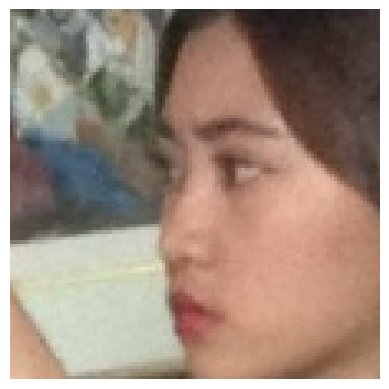

In [4]:
index_map = read_index()
image, label = get_img(index_map[490622])
print(label)
plt.axis('off')
plt.imshow(image)
plt.show()

In [5]:
from src.CasiaWebface import CasiaWebface # type: ignore

In [14]:
dataset = CasiaWebface(rec_path='./data/casia-webface/train.rec',
                       idx_path='./data/casia-webface/train.idx')
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)

In [15]:
print(len(dataloader))

490623


In [16]:
image, label = dataset[len(dataset) - 1]
print(label)

10571


In [17]:
max_label = -1
for img, label in tqdm.tqdm(dataloader):
    max_label = max(max_label, label)
print(max_label)

100%|██████████| 490623/490623 [09:20<00:00, 875.34it/s] 

tensor([10571])
